PART 1 — Structured Data (Titanic CSV)


In [3]:
#Load into Pandas

import pandas as pd

df = pd.read_csv("titanic.csv")
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [4]:
#Identify Missing Values
df.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [5]:
#Drop or Impute

#Impute Age
df['Age'] = df['Age'].fillna(df['Age'].median())


In [6]:
#Drop Cabin

df = df.drop('Cabin', axis=1)


In [7]:
#Remove Duplicates

df = df.drop_duplicates()


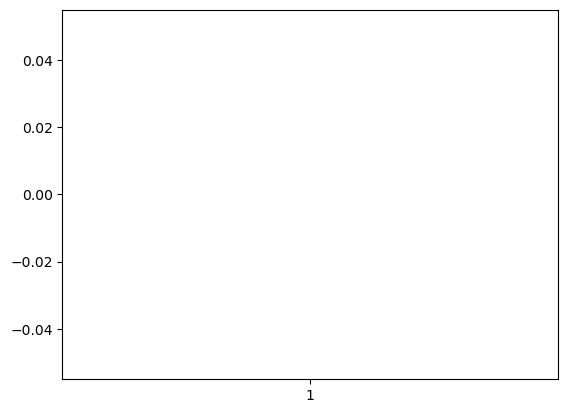

In [8]:
#Detect & Treat Outliers in Fare

import matplotlib.pyplot as plt

plt.boxplot(df['Fare'])
plt.show()


In [9]:
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

df['Fare'] = df['Fare'].clip(lower, upper)


In [10]:
#Fix Data Types

df['Survived'] = df['Survived'].astype(int)
df['Pclass'] = df['Pclass'].astype(int)
df['Sex'] = df['Sex'].astype('category')
df['Embarked'] = df['Embarked'].astype('category')


In [11]:
df.to_csv("titanic_clean.csv", index=False)


___Summary___

Structured Dataset: Titanic

Loaded data using Pandas

Identified missing values in Age and Cabin

Imputed Age using median

Dropped Cabin due to excessive missing data

Removed duplicate rows

Detected outliers in Fare using IQR and capped extreme values

Corrected data types for categorical and numerical columns

Saved cleaned dataset as titanic_clean.csv